# Fusion3 results

**Quantification workflow:** DDA  
**Preprocessing profile:** `dda_missingness_v1`

The VAE is trained on good QC samples, and the MLP classifies good and bad samples from the eight-dimensional VAE latent mean. The table below reports the five folds used in the manuscript analysis.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd().resolve()
project_root = next(
    (
        candidate
        for candidate in [cwd, *cwd.parents]
        if (candidate / "results" / "summary_metrics.csv").exists()
    ),
    None,
)
if project_root is None:
    raise RuntimeError("Run this notebook from inside the project repository.")


In [2]:
summary = pd.read_csv(project_root / 'results' / 'summary_metrics.csv')
folds = pd.read_csv(project_root / 'results' / 'cv_metrics.csv')
display(summary[summary['instrument'] == 'fusion3'].round(4))
display(folds[folds['instrument'] == 'fusion3'].round(4))

,instrument,quantification,n_samples,n_good,n_bad,auc_mean,auc_sd,accuracy_mean,f1_bad_mean
1,fusion3,DDA,120,66,54,0.9646,0.0257,0.9582,0.9512


,instrument,quantification,fold,auc,accuracy,precision_bad,recall_bad,specificity_good,f1_bad,threshold
5,fusion3,DDA,1,1.000,1.000,1.000,1.000,1.000,1.000,0.9898
6,fusion3,DDA,2,0.972,0.958,1.000,0.909,1.000,0.952,0.4268
7,fusion3,DDA,3,0.972,0.958,0.917,1.000,0.923,0.957,0.8005
8,fusion3,DDA,4,0.958,0.917,1.000,0.818,1.000,0.900,0.9816
9,fusion3,DDA,5,0.921,0.958,1.000,0.900,1.000,0.947,0.9882


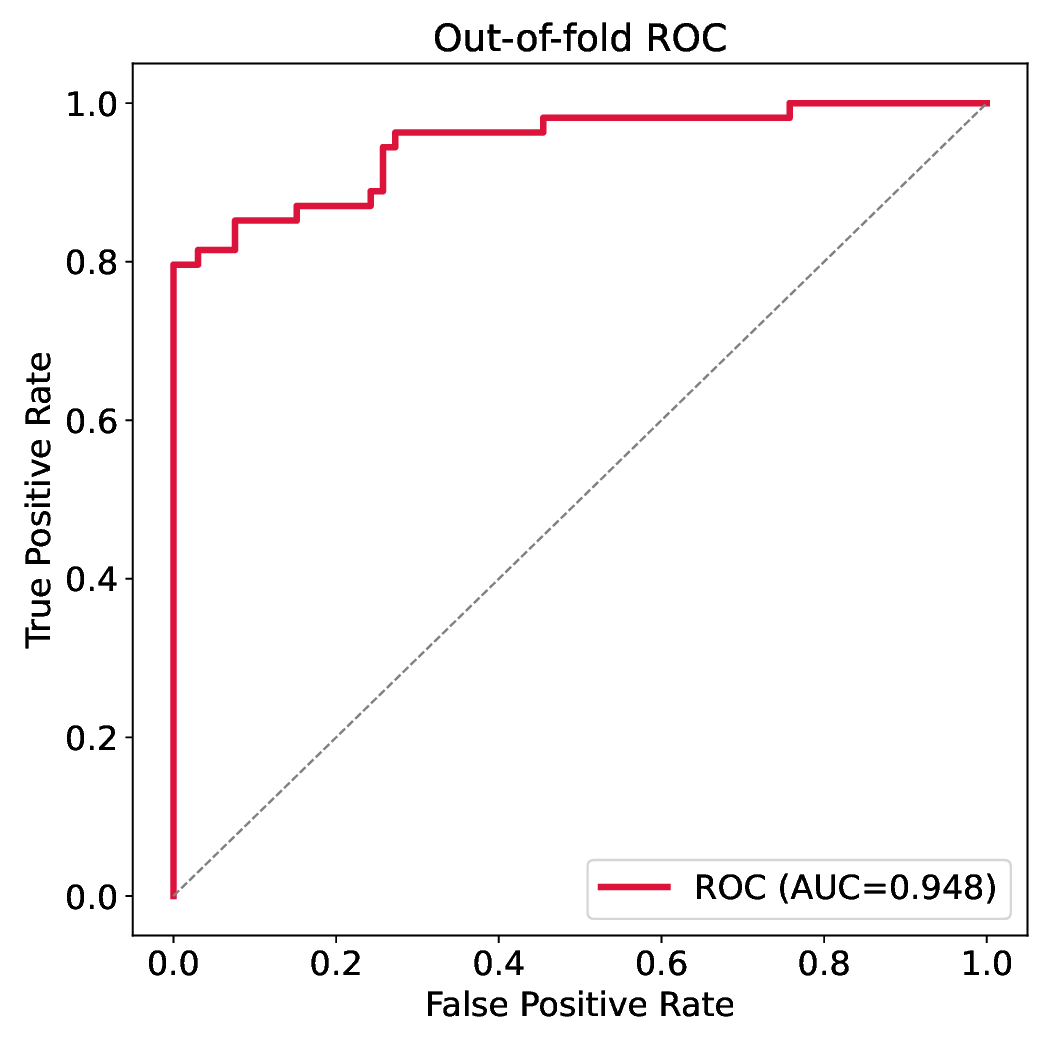

In [3]:
display(Image(filename=project_root / 'results' / 'figures' / 'roc' / 'fusion3_roc.png'))

## Reuse

The pretrained checkpoint is distributed as `fusion3.pt` with the data and model archive. See the repository README for download and inference commands.